Visualizing: BloodImage_00000.xml


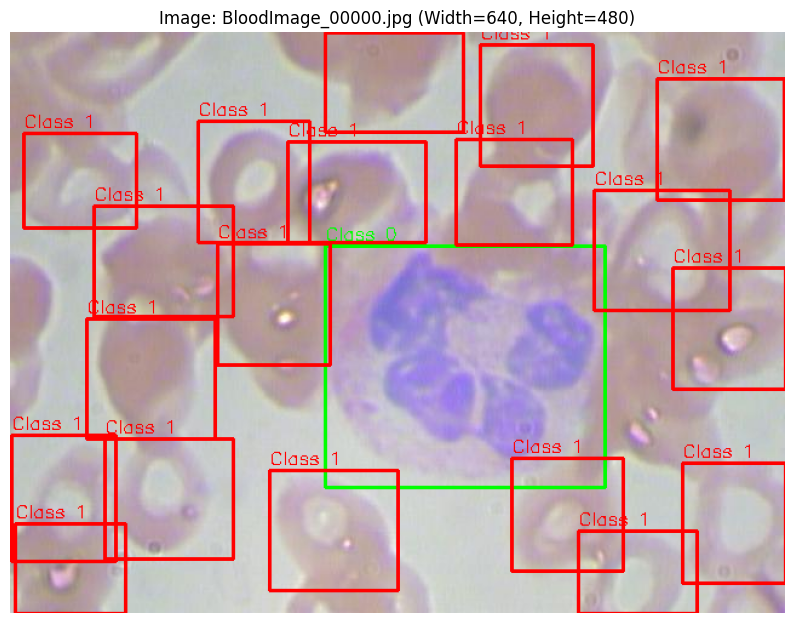

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


import sys
sys.path.append(str(Path.cwd().parent))
from src.data.preprocessing import parse_voc_xml, convert_voc_to_yolo

data_dir = Path("../data/raw/detection/bccd")
images_dir = data_dir / "images"
labels_dir = data_dir / "labels"


xml_file = list(labels_dir.glob("*.xml"))[0]
print(f"Visualizing: {xml_file.name}")


img_filename, width, height, objects = parse_voc_xml(xml_file)
img_path = images_dir / img_filename


image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape


for obj in objects:
    xmin, ymin, xmax, ymax = obj["bbox"]
    xmin, ymin, xmax, ymax = int(xmin), int(ymin), int(xmax), int(ymax)
    
   
    color = (0, 255, 0) if obj["class_id"] == 0 else (255, 0, 0)  # WBC=Green, RBC=Red
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 2)
    cv2.putText(image, f"Class {obj['class_id']}", (xmin, ymin-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)


plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Image: {img_filename} (Width={width}, Height={height})")
plt.show()

In [2]:

print("\n--- YOLO Format Example (Normalized) ---")
if objects:
    yolo_bbox = convert_voc_to_yolo(objects[0]["bbox"], width, height)
    print(f"Class ID: {objects[0]['class_id']}")
    print(f"YOLO coords (center_x, center_y, w, h): {yolo_bbox}")


--- YOLO Format Example (Normalized) ---
Class ID: 0
YOLO coords (center_x, center_y, w, h): [0.58671875, 0.5760416666666667, 0.3609375, 0.41458333333333336]
